In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [16]:
from math import isnan
df = pd.read_csv("../dataset/Crop_recommendation.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.isna().sum())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
(2200, 8)
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [17]:
df.info()
df.describe()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [19]:
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

# **Data Cleaning**

In [20]:

df.isnull().sum()
# df.fillna(df.mean(), inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

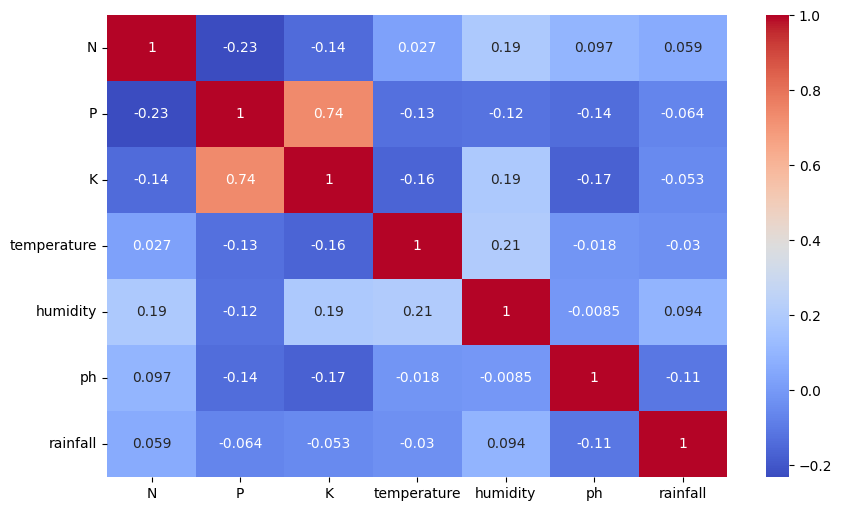

In [21]:
plt.figure(figsize=(10,6))
cor_rel_df=df.drop('label',axis=1)#droppoped label column
sns.heatmap(cor_rel_df.corr(), annot=True, cmap="coolwarm")
plt.show()

# **Crop Distribution**

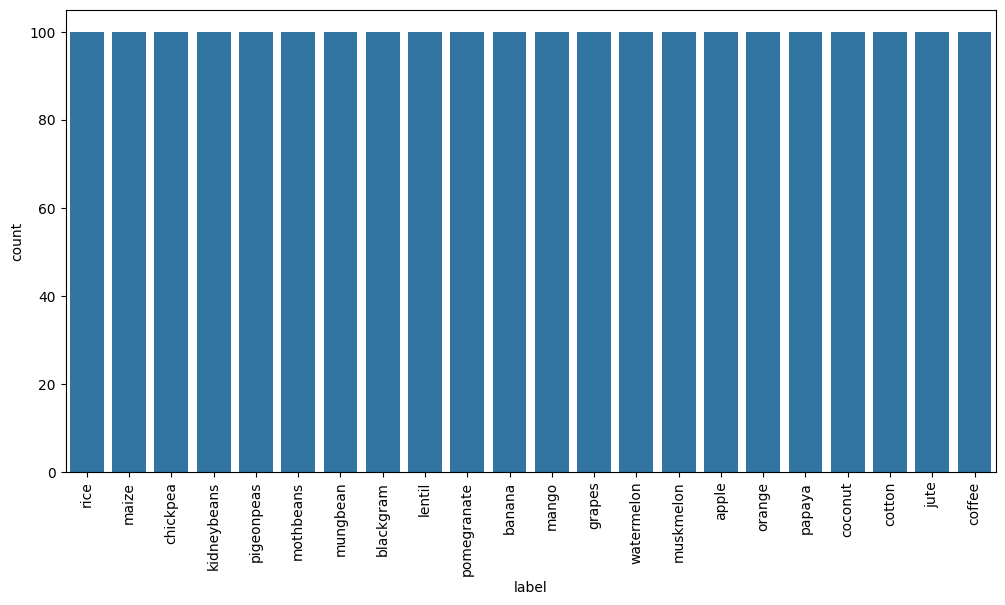

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.show()

In [23]:
X = df.drop('label', axis=1)   # input features
y = df['label']                # target

In [24]:
#converting crop names into numbers
le = LabelEncoder()
y = le.fit_transform(y)

In [25]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# Split dataset into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [27]:
models = {

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(n_estimators=100),

"SVM": SVC(),

"KNN": KNeighborsClassifier(),

"Naive Bayes": GaussianNB()

}

# **Model Training**

In [28]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print(name, "Accuracy:", accuracy)

Decision Tree Accuracy: 0.9840909090909091
Random Forest Accuracy: 0.9931818181818182
SVM Accuracy: 0.9681818181818181
KNN Accuracy: 0.9568181818181818
Naive Bayes Accuracy: 0.9954545454545455


In [29]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

Best Model: Naive Bayes
Best Accuracy: 0.9954545454545455


In [30]:
best_model = models[best_model_name]

sample = [[90,42,43,20.8,82,6.5,202]]

sample = scaler.transform(sample)

prediction = best_model.predict(sample)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


c:\Users\Vinayak Potdar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
model = GaussianNB()

model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [32]:
y_pred = model.predict(X_test)

In [33]:
accuracy_score(y_test, y_pred)

0.9954545454545455

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

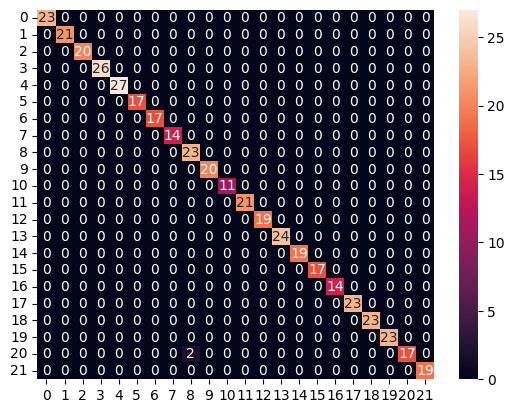

In [35]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

In [36]:
sample = [[90,42,43,21,82,6.5,200]]
#scaling sample data
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

crop = le.inverse_transform(prediction)#numerical prediction back into its original

print("Recommended Crop:", crop[0])

Recommended Crop: rice


c:\Users\Vinayak Potdar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
import pickle

pickle.dump(model, open("crop_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))
pickle.dump(le, open("label_encoder.pkl","wb"))

In [38]:
import pickle

# Load the model, scaler, and label encoder
loaded_model = pickle.load(open("crop_model.pkl", "rb"))#GaussianNB model
loaded_scaler = pickle.load(open("scaler.pkl", "rb"))#StandardScaler fitted to data
loaded_le = pickle.load(open("label_encoder.pkl", "rb"))#LabelEncoder converting crops to nums and also backward.

print("Files loaded successfully!")

Files loaded successfully!


In [39]:
# Example new sample data (N, P, K, temperature, humidity, ph, rainfall)
new_sample = [[80, 50, 45, 23.5, 75.0, 6.8, 150.0]]

# Scale the new sample using the loaded scaler
new_sample_scaled = loaded_scaler.transform(new_sample)

# Make a prediction using the loaded model
new_prediction_encoded = loaded_model.predict(new_sample_scaled)

# Inverse transform the prediction to get the crop name
recommended_crop = loaded_le.inverse_transform(new_prediction_encoded)

print("For the given conditions, the recommended crop is:", recommended_crop[0])

For the given conditions, the recommended crop is: jute


c:\Users\Vinayak Potdar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [40]:
from sklearn.metrics import cohen_kappa_score

kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

Cohen's Kappa Score: 0.9952


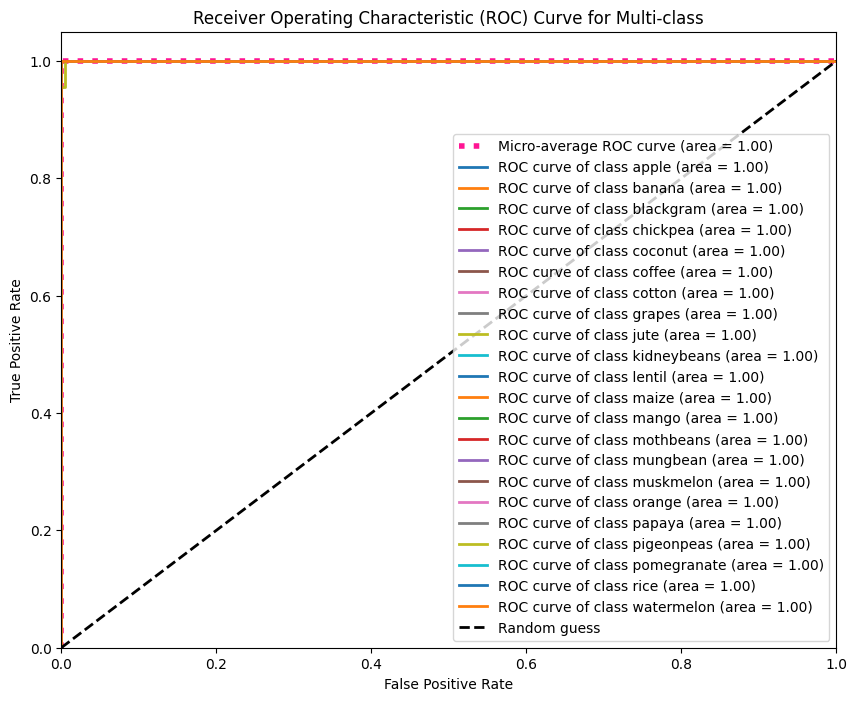

In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for the test set
y_pred_proba = model.predict_proba(X_test)

# Binarize y_test for multi-class ROC calculation
n_classes = len(loaded_le.classes_)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {loaded_le.inverse_transform([i])[0]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

In [42]:
from sklearn.model_selection import KFold, cross_val_score

# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42) # Using 5 splits (common practice)

# Perform K-fold cross-validation
cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='accuracy')

print(f"K-Fold Cross-Validation Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

K-Fold Cross-Validation Accuracies: [0.99545455 0.99090909 0.99545455 0.99545455 0.99772727]
Mean CV Accuracy: 0.9950
Standard Deviation of CV Accuracy: 0.0022


## Load and Explore District Data


In [ ]:
df_district = pd.read_csv('./crop_data_district.csv')
print(df_district.head())
print(df_district.info())

   Dist Code  Year  State Code    State Name Dist Name  RICE AREA (1000 ha)  \
0          1  1990          14  Chhattisgarh      Durg                397.9   
1          1  1991          14  Chhattisgarh      Durg                393.2   
2          1  1992          14  Chhattisgarh      Durg                398.4   
3          1  1993          14  Chhattisgarh      Durg                410.2   
4          1  1994          14  Chhattisgarh      Durg                430.1   

   RICE PRODUCTION (1000 tons)  RICE YIELD (Kg per ha)  WHEAT AREA (1000 ha)  \
0                        481.4                  1210.0                  18.2   
1                        508.6                  1293.0                  18.3   
2                        514.5                  1291.0                  17.1   
3                        569.1                  1387.0                  17.0   
4                        601.7                  1399.0                  17.5   

   WHEAT PRODUCTION (1000 tons)  ...  SUGARC

## Determine Top 3 Probable Crops



In [ ]:
# sample_conditions = [[90, 42, 43, 20.8, 82, 6.5, 202]]

# sample_scaled_top3 = loaded_scaler.transform(sample_conditions)

# probabilities = loaded_model.predict_proba(sample_scaled_top3)[0]
# # print(loaded_le.classes_)
# all_crop_names = loaded_le.inverse_transform(range(len(loaded_le.classes_)))
# # print(all_crop_names)
# probability_series = pd.Series(probabilities, index=all_crop_names)
# print(probability_series)
# top_3_crops = probability_series.nlargest(3)

# print("Top 3 Recommended Crops and their probabilities:")
# print(top_3_crops)

In [ ]:
sample_conditions = [[90, 42, 43, 20.8, 82, 6.5, 202]]

# Get the feature names from the original DataFrame X
feature_names = X.columns

# Convert the sample conditions to a DataFrame with the correct column names
sample_df = pd.DataFrame(sample_conditions, columns=feature_names)
# print(sample_df)
sample_scaled_top3 = loaded_scaler.transform(sample_df)

probabilities = loaded_model.predict_proba(sample_scaled_top3)[0]

all_crop_names = loaded_le.inverse_transform(range(len(loaded_le.classes_)))

probability_series = pd.Series(probabilities, index=all_crop_names)

top_3_crops = probability_series.nlargest(3)

print("Top 3 Recommended Crops and their probabilities:")
print(top_3_crops)

Top 3 Recommended Crops and their probabilities:
rice      9.973435e-01
jute      2.656493e-03
coffee    1.021086e-10
dtype: float64


## Filter Top Crops by District Suitability


In [ ]:
district_name = "Durg"
year = 1990

df_district_filtered = df_district[
    (df_district["Dist Name"] == district_name) &
    (df_district["Year"] == year)
]

if df_district_filtered.empty:
    print("No district data found")
    exit()

# -----------------------------
# GET CROP AREA COLUMNS
# -----------------------------

crop_area_columns = [
    col for col in df_district_filtered.columns
    if "AREA (1000 ha)" in col
]
print(crop_area_columns)
# -----------------------------
#CROP NAME MAPPING
# -----------------------------

crop_mapping = {
    "jowar": "maize",
    "tur": "pigeonpeas",
    "arhar": "pigeonpeas",
    "gram": "chickpea",
    "moong": "mungbean",
    "urad": "blackgram",
    "masoor": "lentil"
}

suitable_crops_in_district = []

# -----------------------------
# EXTRACT CROPS GROWN IN DISTRICT
# -----------------------------

for col in crop_area_columns:

    if df_district_filtered[col].iloc[0] > 0:

        crop_name = col.split(" AREA")[0].strip().lower()

        crop_name = crop_mapping.get(crop_name, crop_name)

        if crop_name in all_crop_names:
            suitable_crops_in_district.append(crop_name)

# remove duplicates
suitable_crops_in_district = list(set(suitable_crops_in_district))

print("\nCrops grown in district:")
print(suitable_crops_in_district)

# FINAL HYBRID FILTER
final_recommended_crops = [
    crop for crop in top_3_crops.index
    if crop in suitable_crops_in_district
]

# If no match found
if len(final_recommended_crops) == 0:
    final_recommended_crops = [top_3_crops.index[0]]

print("\nFinal Recommended Crops:")
print(final_recommended_crops)

['RICE AREA (1000 ha)', 'WHEAT AREA (1000 ha)', 'KHARIF SORGHUM AREA (1000 ha)', 'RABI SORGHUM AREA (1000 ha)', 'SORGHUM AREA (1000 ha)', 'PEARL MILLET AREA (1000 ha)', 'MAIZE AREA (1000 ha)', 'FINGER MILLET AREA (1000 ha)', 'BARLEY AREA (1000 ha)', 'CHICKPEA AREA (1000 ha)', 'PIGEONPEA AREA (1000 ha)', 'MINOR PULSES AREA (1000 ha)', 'GROUNDNUT AREA (1000 ha)', 'SESAMUM AREA (1000 ha)', 'RAPESEED AND MUSTARD AREA (1000 ha)', 'SAFFLOWER AREA (1000 ha)', 'CASTOR AREA (1000 ha)', 'LINSEED AREA (1000 ha)', 'SUNFLOWER AREA (1000 ha)', 'SOYABEAN AREA (1000 ha)', 'OILSEEDS AREA (1000 ha)', 'SUGARCANE AREA (1000 ha)', 'COTTON AREA (1000 ha)', 'FRUITS AREA (1000 ha)', 'VEGETABLES AREA (1000 ha)', 'FRUITS AND VEGETABLES AREA (1000 ha)', 'POTATOES AREA (1000 ha)', 'ONION AREA (1000 ha)', 'FODDER AREA (1000 ha)']

Crops grown in district:
['chickpea', 'maize', 'rice']

Final Recommended Crops:
['rice']


## Visualize Filtered Recommendations


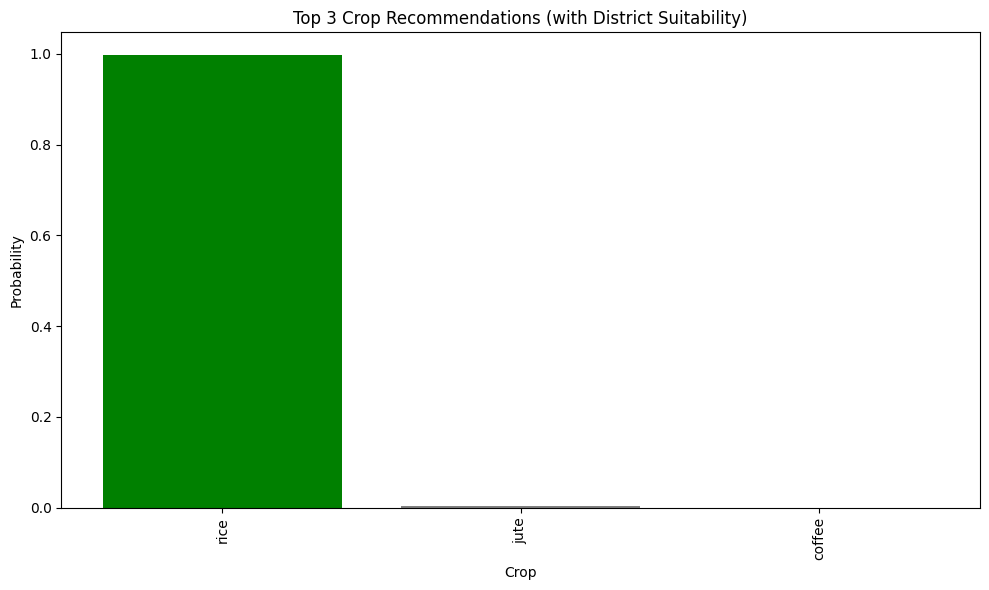

In [ ]:
plt.figure(figsize=(10, 6))

crop_names = top_3_crops.index
probabilities = top_3_crops.values

# Determine colors for bars based on district suitability
colors = ['green' if crop in final_recommended_crops else 'gray' for crop in crop_names]

plt.bar(crop_names, probabilities, color=colors)

plt.xlabel('Crop')
plt.ylabel('Probability')
plt.title('Top 3 Crop Recommendations (with District Suitability)')

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [ ]:
new_sample_2 = [[60, 50, 40, 30.5, 70.0, 7.2, 100.0]]
feature_names = X.columns
sample_df_2 = pd.DataFrame(new_sample_2, columns=feature_names)

sample_scaled_2 = loaded_scaler.transform(sample_df_2)
probabilities_2 = loaded_model.predict_proba(sample_scaled_2)[0]

# Map probabilities to crop names
all_crop_names = loaded_le.inverse_transform(range(len(loaded_le.classes_)))
prob_series_2 = pd.Series(probabilities_2, index=all_crop_names)
top_3_crops_2 = prob_series_2.nlargest(3)

print('New Top 3 Recommended Crops based on Environment:')
print(top_3_crops_2)

# Filter by District Suitability (using existing suitable_crops_in_district)
final_recommended_2 = [
    crop for crop in top_3_crops_2.index
    if crop in suitable_crops_in_district
]

# Fallback to top environmental prediction if no overlap
if not final_recommended_2:
    final_recommended_2 = [top_3_crops_2.index[0]]

print('\nFinal Hybrid Recommendation (Environment + District):')
print(final_recommended_2)

New Top 3 Recommended Crops based on Environment:
jute      0.643269
coffee    0.356567
maize     0.000154
dtype: float64

Final Hybrid Recommendation (Environment + District):
['maize']
